# Modelos ARIMA

Forma práctica cómo implementar un modelo ARIMA, incluyendo la estimación de sus hiper-parámetros p, d y q.

## 1. Lectura y exploración del set de datos

Construiremos un modelo ARIMA para predecir el número de peticiones que recibe un servidor web.

El set de datos contiene un total de 100 registros (uno cada minuto).

Comencemos cargando las librerías necesarias:

In [2]:
# Librerías

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller # <--- Prueba de estacionariedad Dickey-Fuller

# Modelos ARIMA con stasforecast y statsmodels
from statsforecast import StatsForecast
from statsforecast.models import ARIMA
import statsmodels.api as sm



sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 4)

Y ahora leamos el set de datos:

In [3]:
# El set de datos
df = pd.read_csv('datos/peticiones_servidor.csv')
df

,unique_id,ds,y
0,peticiones_servidor_1,1,88
1,peticiones_servidor_1,2,84
2,peticiones_servidor_1,3,85
3,peticiones_servidor_1,4,85
4,peticiones_servidor_1,5,84
...,...,...,...
95,peticiones_servidor_1,96,222
96,peticiones_servidor_1,97,228
97,peticiones_servidor_1,98,226
98,peticiones_servidor_1,99,222


Y hagamos un gráfico de la Serie en el tiempo así como de su valor medio:

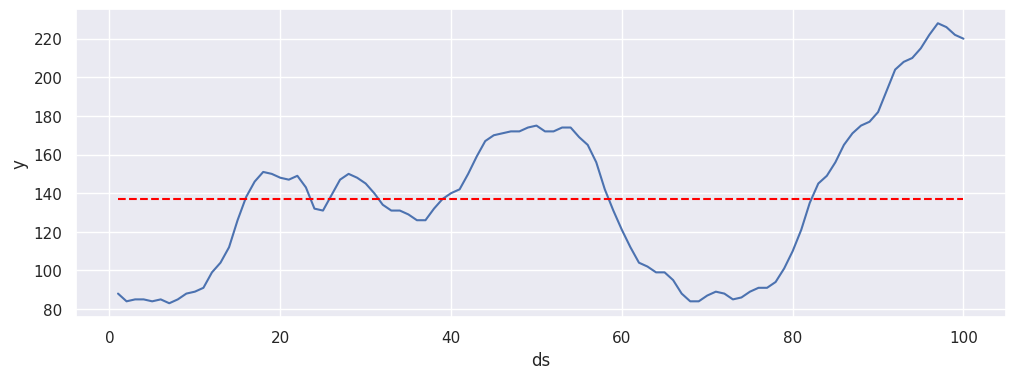

In [4]:
sns.lineplot(df, x="ds", y="y")
plt.hlines(df["y"].mean(), xmin=df["ds"].min(), xmax=df["ds"].max(), color='red', linestyle='--')

**Observaciones:**
- Es una Serie aparentemente NO estacionaria
- Y que no contiene componentes estacionales

Así que resultaría adecuado el uso de un modelo ARIMA.

## 2. Estimación del orden "d"

Este es siempre el primer paso al construir un modelo ARIMA.

Debemos elegir el orden de diferenciación (d) que hace que la Serie pase de ser no estacionaria a estacionaria.

Calculemos dos órdenes de diferenciación y en cada caso dibujemos la Serie obtenida y apliquemos la prueba Dickey Fuller:

In [5]:
def prueba_diferenciacion(serie, d, titulo):
    # Eliminar posibles NaN de la serie
    serie = serie.dropna()

    # Diferenciar (si d!=0)
    if d != 0:
        for _ in range(d):
            serie = serie.diff()

    # Aplicar prueba y mostrar resultado
    resultado = adfuller(serie.dropna())
    pval = resultado[1]

    if pval < 0.05:
        # Se rechaza la hipótesis nula: la serie es estacionaria
        print(f'La serie es estacionaria porque p = {pval:.2f} < 0.05. NO se requiere diferenciación')
    else:
        # Se acepta la hipótesis nula: la serie es NO estacionaria
        print(f'La serie NO es estacionaria porque p = {pval:.2f} >= 0.05. Se requiere diferenciación')

    # Graficar
    fig, ax = plt.subplots(1,1,figsize=(12,4))
    plt.plot(range(1,len(serie)+1), serie)
    plt.hlines(serie.mean(), xmin=1, xmax=len(serie)+1, color='red', linestyle='--');
    ax.set_title(titulo)

La serie NO es estacionaria porque p = 0.12 >= 0.05. Se requiere diferenciación


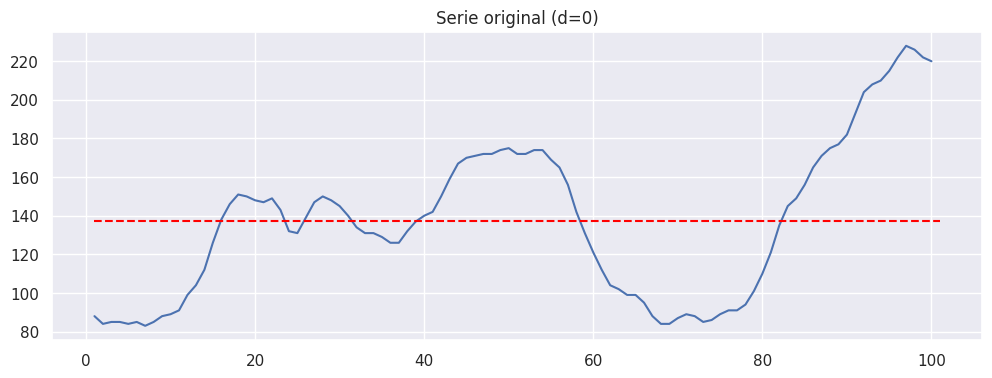

In [6]:
# Serie original
prueba_diferenciacion(df['y'], 0, 'Serie original (d=0)')

La serie NO es estacionaria porque p = 0.07 >= 0.05. Se requiere diferenciación


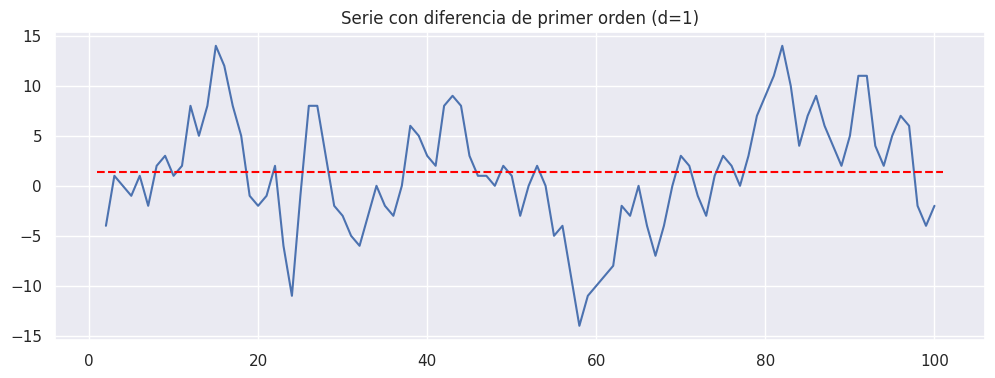

In [7]:
# Serie con d=1
prueba_diferenciacion(df['y'], 1, 'Serie con diferencia de primer orden (d=1)')

La serie es estacionaria porque p = 0.00 < 0.05. NO se requiere diferenciación


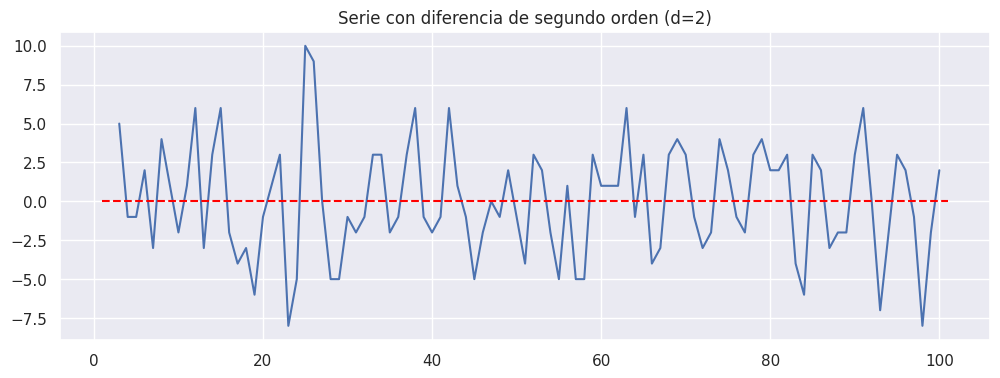

In [8]:
# Serie con d=2
prueba_diferenciacion(df['y'], 2, 'Serie con diferencia de segundo orden (d=2)')

**Observaciones:**
- La serie original es NO estacionaria
- Con d=1 la serie parece no ser estacionaria aunque la prueba arroja un p=0.07, muy cercano a 0.05
- Con d=2 la serie es estacionaria

En la práctica **se sugiere usar el orden de diferenciación (d) más bajo posible**, pues cada vez que se diferencia la serie perderemos información.

Así que implementaremos un modelo con d=1.

## 3. Estimación del orden del modelo auto-regresivo (p)

En este caso tomaremos la primera diferencia y veremos el comportamiento de su PACF:

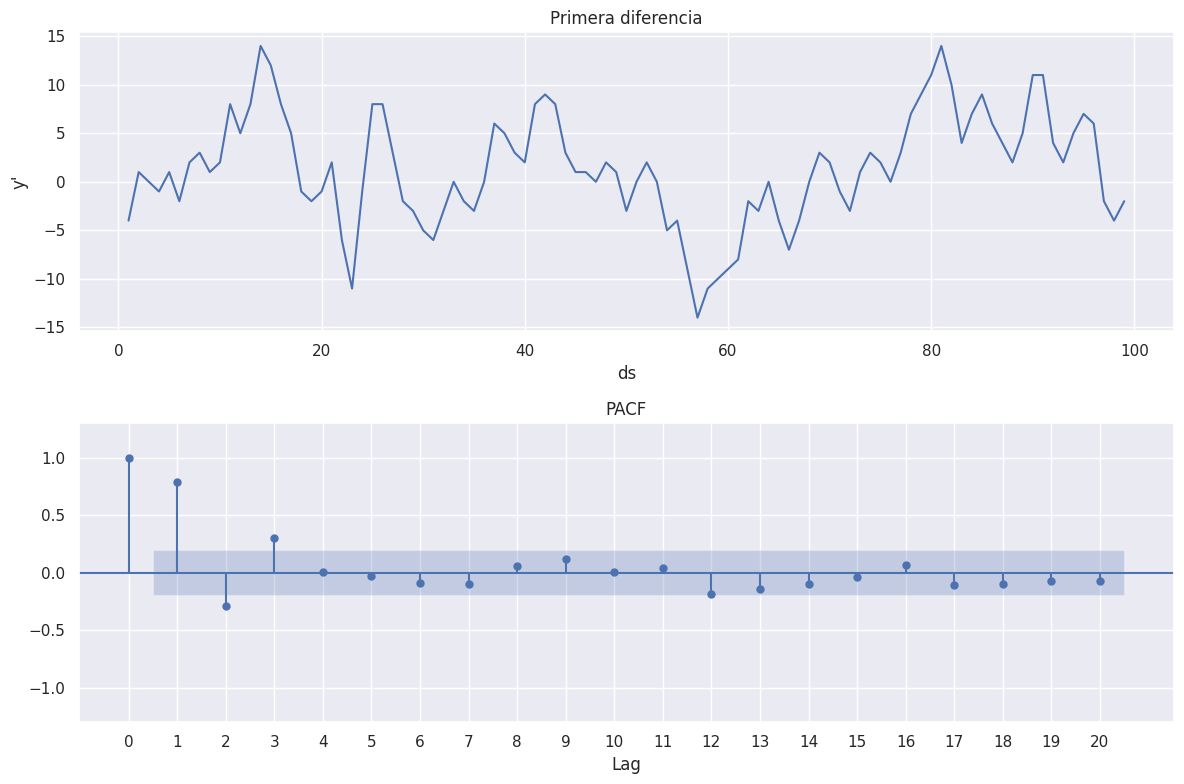

In [9]:
# Calcular primera diferencia de la Serie
df_dif1 = df['y'].diff().dropna()

# Dibujar serie diferenciada y función de autocorrelación parcial
fig, axs = plt.subplots(2,1,figsize=(12,8))

sns.lineplot(df_dif1, ax=axs[0])
axs[0].set_xlabel('ds')
axs[0].set_ylabel("y'")
axs[0].set_title('Primera diferencia')

LAGS = 20
plot_pacf(df_dif1,
        alpha=0.05, # Intervalo de confianza del 95%
        lags=LAGS,
        ax=axs[1])
axs[1].set_xlabel('Lag')
axs[1].set_xticks(range(0,LAGS+1))
axs[1].set_title('PACF')
axs[1].set_ylim([-1.3, 1.3])
axs[1].grid(True)

plt.tight_layout()

**Observaciones:**
- Vemos claramente el comportamiento esperado para la PACF: decae abruptamente después del lag = 3
- Así que escogeremos un orden p=3

## 4. Estimación del orden del modelo de media móvil (q)

En este caso tomamos la serie con diferenciación de primer orden y dibujamos su ACF:

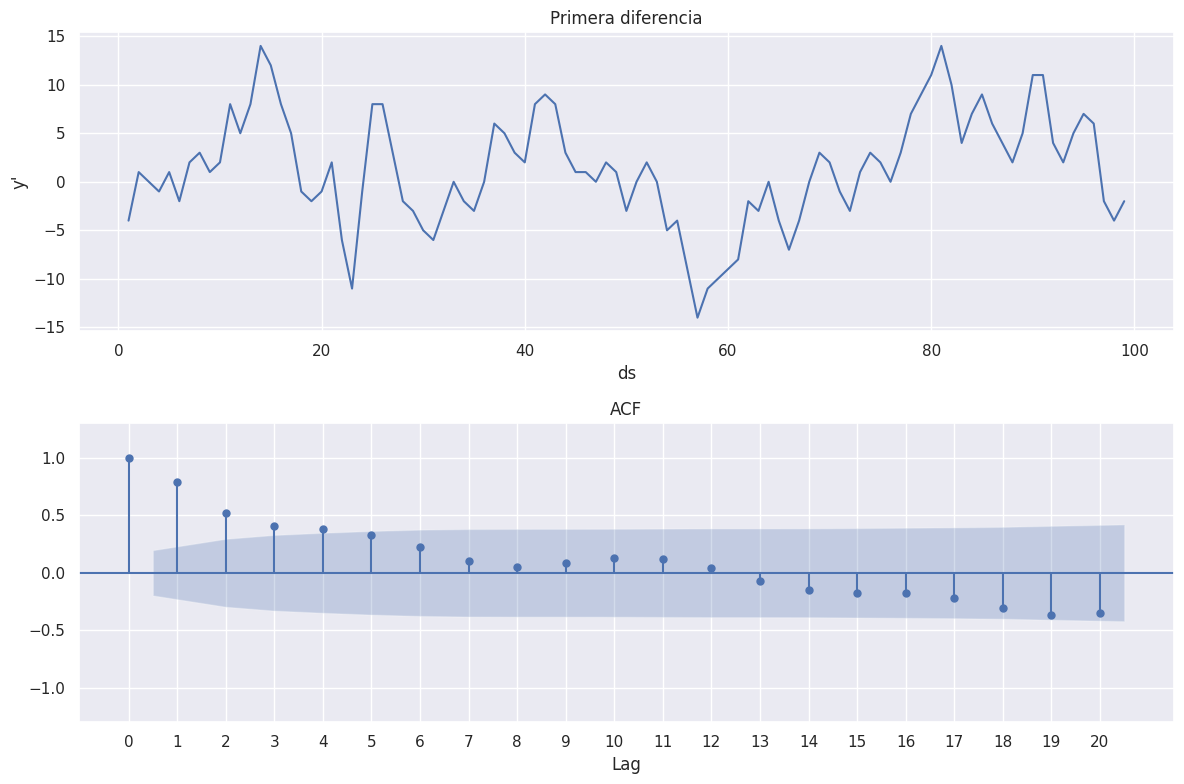

In [10]:
# Calcular primera diferencia de la Serie
df_dif1 = df['y'].diff().dropna()

# Dibujar serie diferenciada y función de autocorrelación
fig, axs = plt.subplots(2,1,figsize=(12,8))

sns.lineplot(df_dif1, ax=axs[0])
axs[0].set_xlabel('ds')
axs[0].set_ylabel("y'")
axs[0].set_title('Primera diferencia')

LAGS = 20
plot_acf(df_dif1,
        alpha=0.05, # Intervalo de confianza del 95%
        lags=LAGS,
        ax=axs[1])
axs[1].set_xlabel('Lag')
axs[1].set_xticks(range(0,LAGS+1))
axs[1].set_title('ACF')
axs[1].set_ylim([-1.3, 1.3])
axs[1].grid(True)

plt.tight_layout()

**Observaciones:**
- Vemos que la ACF tiene un comportamiento esperado para un modelo MA: decae abruptamente después de 3-4 lags
- Asumiremos un q=4 (y en la próxima lección veremos cómo escoger los hiper-parámetros p, q y d cuando no tenemos claros sus valores)

## 5. Entrenamiento del modelo ARIMA

Veamos cómo entrenar el modelo usando tanto StatsForecast como la librería statsmodels.

En ambos casos construiremos un modelo MA(p=3, d=1, q=4). Veamos primero el modelo en StatsForecast:

In [11]:
# Instancia del modelo
models = [ARIMA(order=(3, 1, 4), alias="ARIMA(3,1,4)", include_constant=True)]
sf = StatsForecast(models=models,
                freq=1, # La frecuencia de la serie es simplemente un entero
                )

# Entrenar con fit
sf.fit(df)

StatsForecast(models=[ARIMA(3,1,4)])

En el caso anterior hemos decidido incluir de manera explícita la constante del modelo ("include_constant=True)). En un momento veremos qué efecto tiene esto.

Una vez entrenado el modelo podemos extraer toda su información accediendo al atributo "fitted_":

In [12]:
modelo_sf = sf.fitted_[0][0].model_
modelo_sf

{'coef': {'ar1': np.float64(-0.6144487371633338),
  'ar2': np.float64(0.6981964403345686),
  'ar3': np.float64(0.4022160736073531),
  'ma1': np.float64(1.967754676302672),
  'ma2': np.float64(0.9277488826842513),
  'ma3': np.float64(-0.37707423882716085),
  'ma4': np.float64(-0.37728092003987346),
  'drift': np.float64(1.0736796262895794)},
 'sigma2': np.float64(8.57017452899643),
 'var_coef': array([[ 3.27172231e-03, -4.73550090e-05, -3.81596316e-03,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00],
        [-4.73550090e-05,  3.32083581e-03,  2.82247602e-03,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00],
        [-3.81596316e-03,  2.82247602e-03,  7.09142599e-03,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          1.01010101e-02,  0.00000000e+00,  0.000000

Y veamos los parámetros del modelo:

In [13]:
# Extraer los parámetros del modelo entrenado
params = modelo_sf['coef']

# Imprimir
for name, value in params.items():
    print(f"Parámetro {name:10} : {value:.4f}")


Parámetro ar1        : -0.6144
Parámetro ar2        : 0.6982
Parámetro ar3        : 0.4022
Parámetro ma1        : 1.9678
Parámetro ma2        : 0.9277
Parámetro ma3        : -0.3771
Parámetro ma4        : -0.3773
Parámetro drift      : 1.0737


Así que este modelo es de la forma:

$$(1+0.6263B-0.6824B^2-0.3978B^3)(1-B)^1y_t = 1.0122 + (1+1.9983B+1.0298B^2-0.2445B^3-0.3153B^4)\epsilon_t$$

Y vemos además que la constante es denominada como "drift" o deriva.

Veamos cómo hacer lo mismo pero con "statsmodels":

In [14]:
# orden: (p, d, q)
modelo_sm = sm.tsa.ARIMA(df['y'], order=(3,1,4), trend='t')
resultados = modelo_sm.fit()

# Con statsmodels es muy sencillo acceder a la información del modelo
print(resultados.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  100
Model:                 ARIMA(3, 1, 4)   Log Likelihood                -248.640
Date:                Sat, 02 May 2026   AIC                            515.280
Time:                        20:30:21   BIC                            538.636
Sample:                             0   HQIC                           524.730
                                - 100                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.6156      1.505      0.409      0.682      -2.334       3.565
ar.L1          1.5813      0.157     10.093      0.000       1.274       1.888
ar.L2         -1.4964      0.183     -8.192      0.0

/home/jair/anaconda3/envs/series/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


En este caso vemos que los parámetros son MUY diferentes. Esto se debe a:

- Que tenemos muchos parámetros por estimar (3 para el modelo AR, 4 para el modelo q)
- Y a que cada librería usa diferentes expresiones matemáticas para modelos equivalentes y diferentes algoritmos de optimización

Así que lo que debemos hacer es analizar los residuales para ver si algún modelo es "mejor" que el otro (probablemente ambos sean equivalentes):

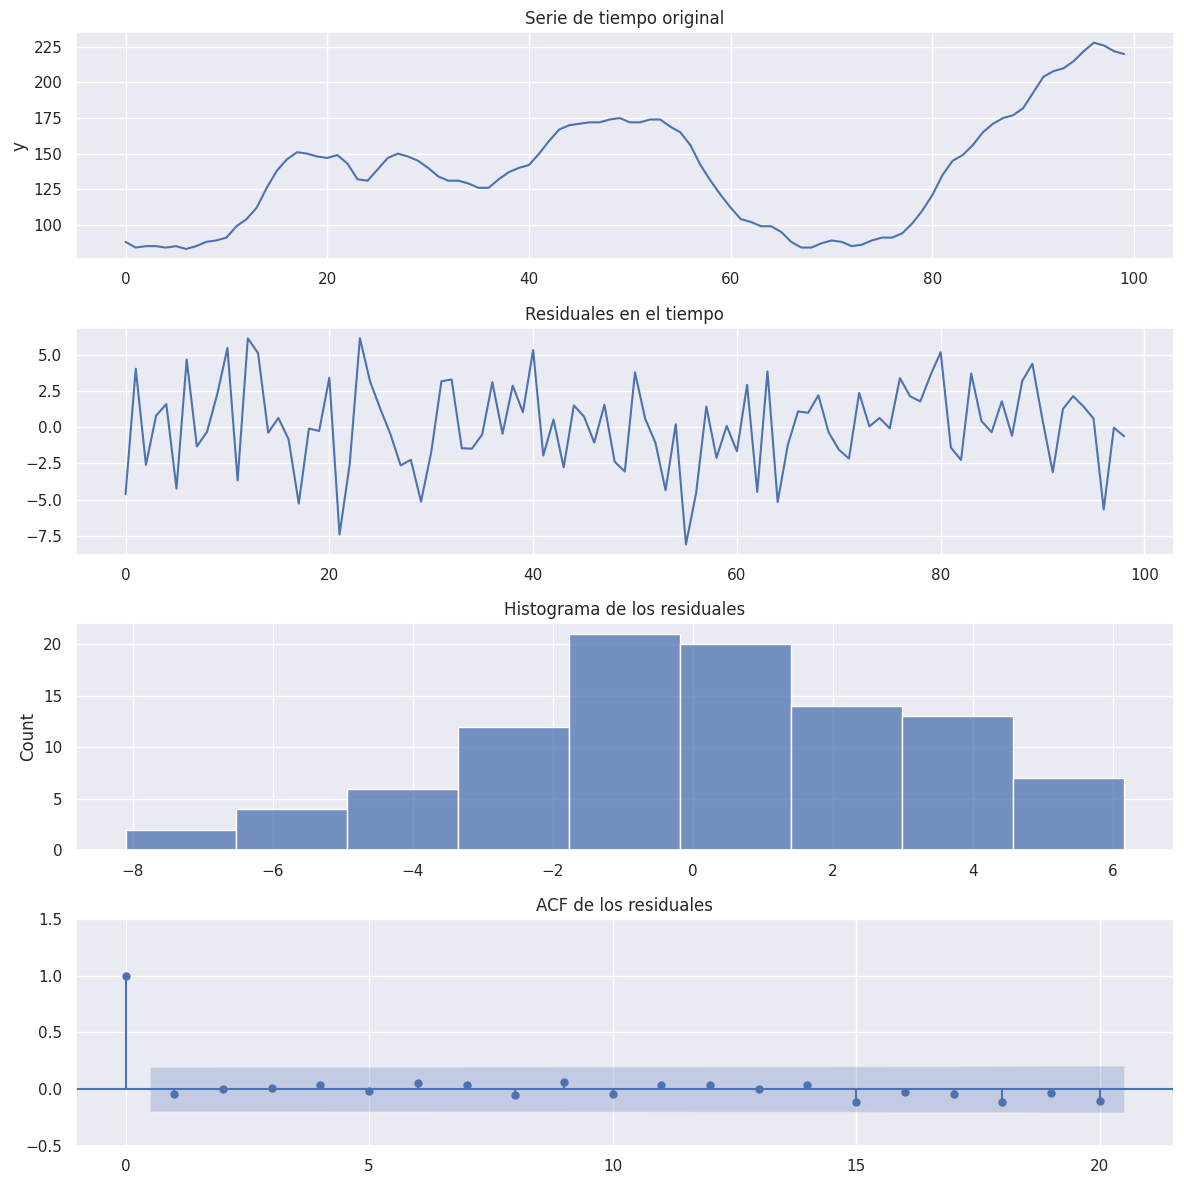

In [15]:
# Extraer residuales (de cualquiera de los dos modelos)
res = modelo_sf['residuals']
res = resultados.resid.values[1:] # res[1:] para remover el primer pico resultado de la inicialización

# Graficar serie, residuales en el tiempo, histograma y ACF de dichos residuales
fig, axs = plt.subplots(4,1,figsize=(12,12))

sns.lineplot(df["y"], ax=axs[0])
axs[0].set_title('Serie de tiempo original')

sns.lineplot(res, ax=axs[1])
axs[1].set_title('Residuales en el tiempo')

sns.histplot(res, ax=axs[2])
axs[2].set_title('Histograma de los residuales')

plot_acf(res, ax=axs[3])
axs[3].set_title('ACF de los residuales')
axs[3].set_ylim([-0.5, 1.5])

plt.tight_layout();

**Observaciones:**

- En el modelo StatsForecast: los residuales oscilan entre -7.5 y 7.5, tienen una media cercana a 0 y no tienen patrones en su ACF
- En el modelo statsmodels: los residuales oscilan entre -7.5 y 5 (ligeramente mejor que statsforecast), pero tienen una media ligeramente mayor a cero (subestiman los valores reales) y no hay patrones en su ACF

Así que podemos decir que desde el punto de vista de los residuales los dos modelos son equivalentes.

## 4. Generación de pronósticos con el modelo ARIMA

Podemos usar StatsForecast y la misma lógica que vimos en la lección anterior para así generar pronósticos.

Supongamos que generaremos un pronóstico a 20 horas y dibujaremos la serie original, el pronóstico puntual y el intervalo de predicción del 90%.

Veamos qué ocurre si incluimos la constante en el modelo:

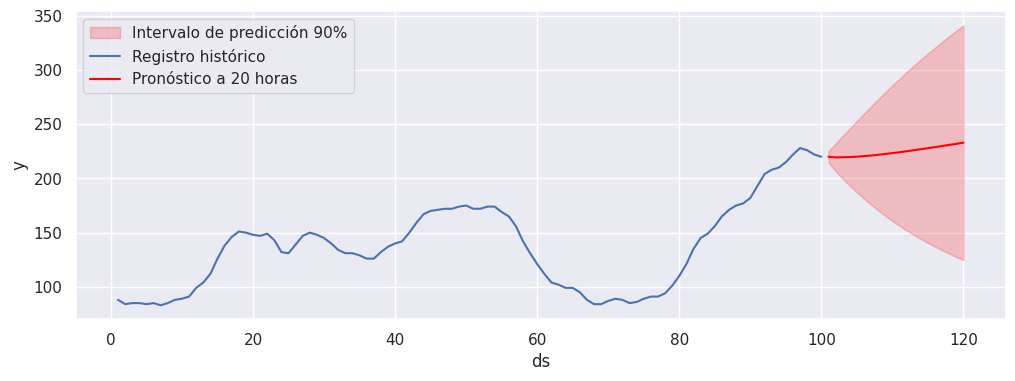

In [16]:
# Instancia modelo ARIMA(3,1,4)
models = [ARIMA(order=(3, 1, 4), alias="ARIMA(3,1,4)", include_constant=True)]
sf = StatsForecast(models=models,
                freq=1, # La frecuencia de la serie es simplemente un entero
                )

# Pronóstico a h=10 horas
fc = sf.forecast(df=df,
                h=20,
                level=[90]
)

# Gráfico serie original, pronóstico e intervalo de predicción
fig, ax = plt.subplots()
plt.fill_between(x=fc["ds"],
                y1 = fc['ARIMA(3,1,4)-lo-90'],
                y2 = fc['ARIMA(3,1,4)-hi-90'],
                color = 'red',
                alpha = 0.2,
                label = 'Intervalo de predicción 90%');
sns.lineplot(df, x="ds", y="y", label='Registro histórico');
sns.lineplot(fc, x="ds", y="ARIMA(3,1,4)", color='red', label='Pronóstico a 20 horas');

Vemos que al incluir la constante ($c\neq0$) los pronósticos tienden a crecer a lo largo del tiempo.

Veamos qué ocurre si no incluimos dicha constante:

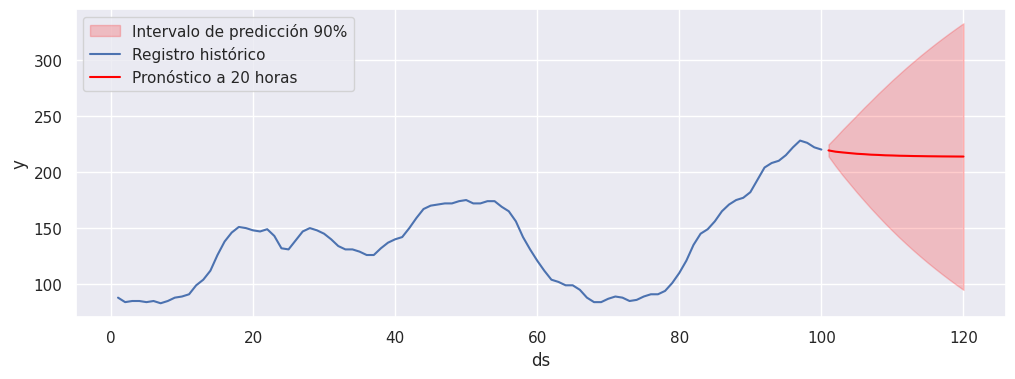

In [17]:
# Instancia modelo AR(2)
models = [ARIMA(order=(3, 1, 4), alias="ARIMA(3,1,4)", include_constant=False)]
sf = StatsForecast(models=models,
                freq=1, # La frecuencia de la serie es simplemente un entero
                )

# Pronóstico a h=10 horas
fc = sf.forecast(df=df,
                h=20,
                level=[90]
)

# Gráfico serie original, pronóstico e intervalo de predicción
fig, ax = plt.subplots()
plt.fill_between(x=fc["ds"],
                y1 = fc['ARIMA(3,1,4)-lo-90'],
                y2 = fc['ARIMA(3,1,4)-hi-90'],
                color = 'red',
                alpha = 0.2,
                label = 'Intervalo de predicción 90%');
sns.lineplot(df, x="ds", y="y", label='Registro histórico');
sns.lineplot(fc, x="ds", y="ARIMA(3,1,4)", color='red', label='Pronóstico a 20 horas');

En este caso ($c=0$) vemos que los pronósticos de la Serie se estabilizan hacia un valor constante.

¿Cuál usar? Al final todo dependerá del desempeño en los pronósticos, desempeño que también dependerá de los valores escogidos para los hiper-parámetros del modelo (p, q, d).